# Plot 5 DDLR subsample split 

Run **wCDM** separately on two subsamples: **low DDLR** (SNe close to host centre) and **high DDLR** (SNe in the outskirts), split at **DDLR = 1**.

Parameters: (omega_m), (w), (M_B), (alpha), (beta), (gamma) (all flat priors), (H_0) fixed at 70. 64 walkers, 5,000 steps each, 20% burnin.

## 1. Install and get data

In [8]:
!pip install -q emcee corner

In [10]:
import os
_cwd = os.getcwd()
_bases = [_cwd, os.path.join(_cwd, "T.O.A.S.T", "MCMC main"), os.path.join(_cwd, "MCMC main")]
DATA_DIR = os.path.join(_cwd, "DES-SN5YR", "4_DISTANCES_COVMAT")
if not os.path.exists(DATA_DIR):
    DATA_DIR = os.path.join(_cwd, "MCMC main", "colab", "DES-SN5YR", "4_DISTANCES_COVMAT")
for _b in _bases:
    _dd = os.path.join(_b, "DES-SN5YR", "4_DISTANCES_COVMAT")
    if os.path.exists(_dd):
        DATA_DIR = _dd
        break
EUCLID_CSV = os.path.join(_cwd, "MCMC main", "colab", "Euclid+data.csv")
if not os.path.exists(EUCLID_CSV):
    EUCLID_CSV = os.path.join(_cwd, "Euclid data", "Euclid+data.csv")
if not os.path.exists(EUCLID_CSV):
    EUCLID_CSV = os.path.join(_cwd, "Euclid+data.csv")
for _b in _bases:
    for _name in ["Euclid+data.csv", os.path.join("Euclid data", "Euclid+data.csv")]:
        _p = os.path.join(_b, _name)
        if os.path.isfile(_p):
            EUCLID_CSV = _p
            break
    else:
        continue
    break
if not os.path.isfile(EUCLID_CSV):
    _p = os.path.join(_cwd, "T.O.A.S.T", "data", "Euclid+data.csv")
    if os.path.isfile(_p):
        EUCLID_CSV = _p
if not os.path.isdir("DES-SN5YR"):
    os.system("git clone https://github.com/des-science/DES-SN5YR.git")

## 2. Load DES data, Euclid DDLR, merge and split at DDLR = 1

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import emcee

DATA_FILE = DATA_DIR + "/DES-Dovekie_HD.csv"
COV_FILE = DATA_DIR + "/STAT+SYS.npz"
H0_FIXED = 70.0
N_WALKERS = 64
N_STEPS = 5000
BURN_IN_FRAC = 0.2
C_KM = 299792.458

PRIORS = {"Omega_m": (0.1, 0.6), "w": (-3.0, 0.0), "M_B": (-31.0, -18.0), "alpha": (0.0, 0.3), "beta": (0.0, 5.0), "gamma": (-0.05, 0.08)}
FIDUCIAL = [0.33, -1.0, -29.96210, 0.169, 3.14, 0.033]

def load_snana_csv(filepath):
    var_names, rows = None, []
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"): continue
            if line.startswith("VARNAMES:"):
                var_names = line.replace("VARNAMES:", "").split()
                continue
            if line.startswith("SN:"):
                values = line.replace("SN:", "").split()
                if var_names and len(values) >= len(var_names):
                    rows.append(values[:len(var_names)])
    df = pd.DataFrame(rows, columns=var_names)
    for col in df.columns:
        if col != "CID": df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

def load_cov_npz(filepath):
    d = np.load(filepath)
    n = int(d["nsn"][0])
    inv_cov = np.zeros((n, n))
    inv_cov[np.triu_indices(n)] = d["cov"]
    inv_cov[np.tril_indices(n, -1)] = inv_cov.T[np.tril_indices(n, -1)]
    return inv_cov

# Load DES HD and covariance
df = load_snana_csv(DATA_FILE)
mask = df["zHD"] > 0
df = df[mask].reset_index(drop=True)
df["_idx"] = np.arange(len(df))
z_all = df["zHD"].values
mu_err_all = df["MUERR"].values
inv_cov_full = load_cov_npz(COV_FILE)
inv_cov_full = inv_cov_full[mask][:, mask]

# Metadata: x0, x1, c, biasCor_mu, HOST_LOGMASS, HOST_RA, HOST_DEC
df_meta = load_snana_csv(DATA_DIR + "/DES-Dovekie_Metadata.csv")
df = df.merge(df_meta[["CID", "x0", "x1", "c", "biasCor_mu", "HOST_LOGMASS", "HOST_RA", "HOST_DEC"]], on="CID", how="left")

# mB, x1, c, biasCor_mu, logmass
mB_all = -2.5 * np.log10(df["x0"].values)
x1_all = df["x1"].values
c_all = df["c"].values
biasCor_mu_all = df["biasCor_mu"].values
logmass_all = np.asarray(df["HOST_LOGMASS"].values, dtype=float)

# Load Euclid DDLR and merge on host position (round to avoid float mismatch)
euclid = pd.read_csv(EUCLID_CSV)
euclid["HOST_RA_r"] = np.round(euclid["HOST_RA"].astype(float), 5)
euclid["HOST_DEC_r"] = np.round(euclid["HOST_DEC"].astype(float), 5)
df["HOST_RA_r"] = np.round(df["HOST_RA"].astype(float), 5)
df["HOST_DEC_r"] = np.round(df["HOST_DEC"].astype(float), 5)
df_merged = df.merge(euclid[["HOST_RA_r", "HOST_DEC_r", "DDLR"]].drop_duplicates(subset=["HOST_RA_r", "HOST_DEC_r"]), on=["HOST_RA_r", "HOST_DEC_r"], how="inner")

# Remove inappropriate DDLR sentinel values (e.g. -9.9999999, -99, NaN, inf)
ddlr_raw = df_merged["DDLR"].values.astype(float)
valid_ddlr = np.isfinite(ddlr_raw) & (ddlr_raw > -0.5)
df_merged = df_merged.loc[valid_ddlr].reset_index(drop=True)

orig_idx = df_merged["_idx"].values.astype(int)
ddlr = df_merged["DDLR"].values
ddlr_split = 1.0  # split at DDLR = 1 (not median...try 1.5)
low_mask = ddlr <= ddlr_split
high_mask = ddlr > ddlr_split
low_idx = orig_idx[low_mask]
high_idx = orig_idx[high_mask]

print(f"Matched {len(orig_idx)} SNe with Euclid DDLR. Split at DDLR = {ddlr_split}")
print(f"Low DDLR (close to centre): {len(low_idx)} SNe")
print(f"High DDLR (outskirts): {len(high_idx)} SNe")

Matched 505 SNe with Euclid DDLR. Split at DDLR = 1.0
Low DDLR (close to centre): 241 SNe
High DDLR (outskirts): 264 SNe


## 3. Build subsample arrays and define cosmology / likelihood

In [ ]:
def get_subsample(indices):
    z = z_all[indices]
    mB = mB_all[indices]
    x1 = x1_all[indices]
    c = c_all[indices]
    biasCor_mu = biasCor_mu_all[indices]
    logmass = logmass_all[indices]
    has_mass = np.isfinite(logmass) & (logmass > 0) & (logmass < 15)
    inv_cov = inv_cov_full[np.ix_(indices, indices)]
    return z, mB, x1, c, biasCor_mu, logmass, has_mass, inv_cov

def mu_tripp(alpha, beta, gamma, M_B, mB, x1, c, biasCor_mu, logmass, has_mass):
    gamma_term = np.where(has_mass, np.where(logmass >= 10.0, -gamma / 2.0, gamma / 2.0), 0.0)
    return mB + (alpha * x1) - (beta * c) + gamma_term - biasCor_mu - M_B

def distance_modulus(z, Omega_m, w, H0):
    Omega_de = 1.0 - Omega_m
    def E(zp):
        return np.sqrt(Omega_m * (1 + zp)**3 + Omega_de * (1 + zp)**(3 * (1 + w)))
    z_vals = np.atleast_1d(z)
    z_max = float(z_vals.max())
    n_grid = 400
    z_grid = np.linspace(0, z_max, n_grid)
    E_grid = E(z_grid)
    integrand = 1.0 / E_grid
    D_grid = np.concatenate([[0], np.cumsum(0.5 * (integrand[1:] + integrand[:-1]) * np.diff(z_grid))])
    d_c = C_KM * np.interp(z_vals, z_grid, D_grid) / H0
    return 5.0 * np.log10((1 + z_vals) * d_c) + 25.0

def make_log_posterior(z, mB, x1, c, biasCor_mu, logmass, has_mass, inv_cov):
    def log_prior(theta):
        Omega_m, w, M_B, alpha, beta, gamma = theta
        if not (PRIORS["Omega_m"][0] < Omega_m < PRIORS["Omega_m"][1]): return -np.inf
        if not (PRIORS["w"][0] < w < PRIORS["w"][1]): return -np.inf
        if not (PRIORS["M_B"][0] < M_B < PRIORS["M_B"][1]): return -np.inf
        if not (PRIORS["alpha"][0] < alpha < PRIORS["alpha"][1]): return -np.inf
        if not (PRIORS["beta"][0] < beta < PRIORS["beta"][1]): return -np.inf
        if not (PRIORS["gamma"][0] < gamma < PRIORS["gamma"][1]): return -np.inf
        return 0.0

    def log_likelihood(theta):
        Omega_m, w, M_B, alpha, beta, gamma = theta
        mu_tripp_now = mu_tripp(alpha, beta, gamma, M_B, mB, x1, c, biasCor_mu, logmass, has_mass)
        mu_theory = distance_modulus(z, Omega_m, w, H0_FIXED)
        residuals = mu_tripp_now - mu_theory
        return -0.5 * (residuals @ inv_cov @ residuals)

    def log_posterior(theta):
        lp = log_prior(theta)
        if not np.isfinite(lp): return -np.inf
        return lp + log_likelihood(theta)

    return log_posterior

## 4. Run MCMC for low and high DDLR subsamples

In [ ]:
n_dim = 6
param_names = ["Omega_m", "w", "M_B", "alpha", "beta", "gamma"]
theta0 = np.array(FIDUCIAL)

def run_subsample(name, indices):
    z, mB, x1, c, biasCor_mu, logmass, has_mass, inv_cov = get_subsample(indices)
    log_posterior = make_log_posterior(z, mB, x1, c, biasCor_mu, logmass, has_mass, inv_cov)
    pos = theta0 + 1e-3 * np.random.randn(N_WALKERS, n_dim)
    sampler = emcee.EnsembleSampler(N_WALKERS, n_dim, log_posterior)
    sampler.run_mcmc(pos, N_STEPS, progress=True)
    chains = sampler.get_chain()
    burn_in = int(BURN_IN_FRAC * N_STEPS)
    flat = chains[burn_in:].reshape(-1, n_dim)
    # Autocorrelation time (for error / effective sample size)
    tau = sampler.get_autocorr_time()
    return flat

print("Running MCMC: Low DDLR (close to host centre)...") 
flat_low = run_subsample("low", low_idx)
print("Running MCMC: High DDLR (outskirts)...")
flat_high = run_subsample("high", high_idx)

Running MCMC: Low DDLR (close to host centre)...


100%|██████████| 5000/5000 [01:51<00:00, 44.79it/s]


Running MCMC: High DDLR (outskirts)...


100%|██████████| 5000/5000 [01:25<00:00, 58.67it/s]


## 5. Plot 5  marginalised (w) and (gamma) comparison (1D posteriors)

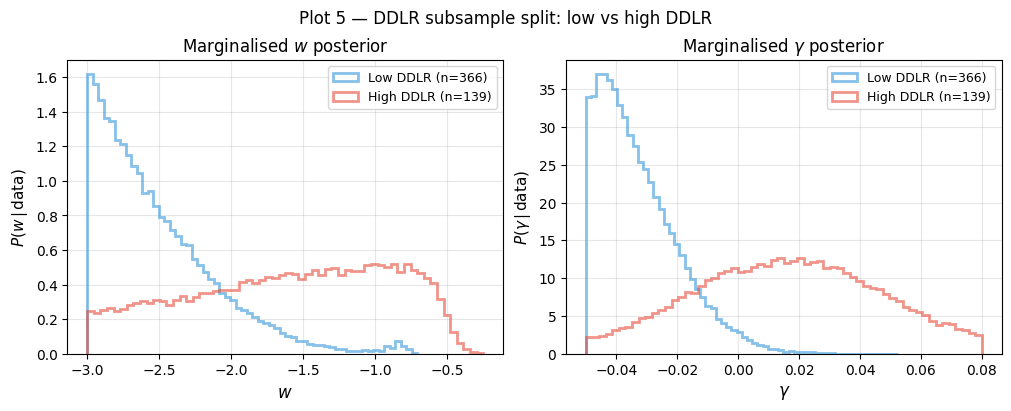

In [ ]:
# w is index 1, gamma is index 5
w_low = flat_low[:, 1]
w_high = flat_high[:, 1]
gamma_low = flat_low[:, 5]
gamma_high = flat_high[:, 5]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

# w posterior comparison
ax1.hist(w_low, bins=60, density=True, alpha=0.6, color="#3498db", label=f"Low DDLR (n={len(low_idx)})", histtype="step", linewidth=2)
ax1.hist(w_high, bins=60, density=True, alpha=0.6, color="#e74c3c", label=f"High DDLR (n={len(high_idx)})", histtype="step", linewidth=2)
ax1.set_xlabel(r"$w$", fontsize=12)
ax1.set_ylabel(r"$P(w\,|\,\mathrm{data})$", fontsize=11)
ax1.set_title(r"Marginalised $w$ posterior")
ax1.legend(loc="upper right", fontsize=9)
ax1.grid(True, alpha=0.3)

# gamma posterior comparison
ax2.hist(gamma_low, bins=60, density=True, alpha=0.6, color="#3498db", label=f"Low DDLR (n={len(low_idx)})", histtype="step", linewidth=2)
ax2.hist(gamma_high, bins=60, density=True, alpha=0.6, color="#e74c3c", label=f"High DDLR (n={len(high_idx)})", histtype="step", linewidth=2)
ax2.set_xlabel(r"$\gamma$", fontsize=12)
ax2.set_ylabel(r"$P(\gamma\,|\,\mathrm{data})$", fontsize=11)
ax2.set_title(r"Marginalised $\gamma$ posterior")
ax2.legend(loc="upper right", fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle("Plot 5 — DDLR subsample split: low vs high DDLR", fontsize=12)
plt.show()

In [ ]:
# Summary median and 68% credible interval for w and gamma
for name, flat in [("Low DDLR", flat_low), ("High DDLR", flat_high)]:
    w = flat[:, 1]
    g = flat[:, 5]
    print(f"{name}: w = {np.median(w):.4f} +{np.percentile(w,84)-np.median(w):.4f} -{np.median(w)-np.percentile(w,16):.4f}")
    print(f"       gamma = {np.median(g):.4f} +{np.percentile(g,84)-np.median(g):.4f} -{np.median(g)-np.percentile(g,16):.4f}")

Low DDLR: w = -2.6184 +0.4952 -0.2789
       gamma = -0.0355 +0.0160 -0.0099
High DDLR: w = -1.5375 +0.6996 -0.8816
       gamma = 0.0161 +0.0311 -0.0313


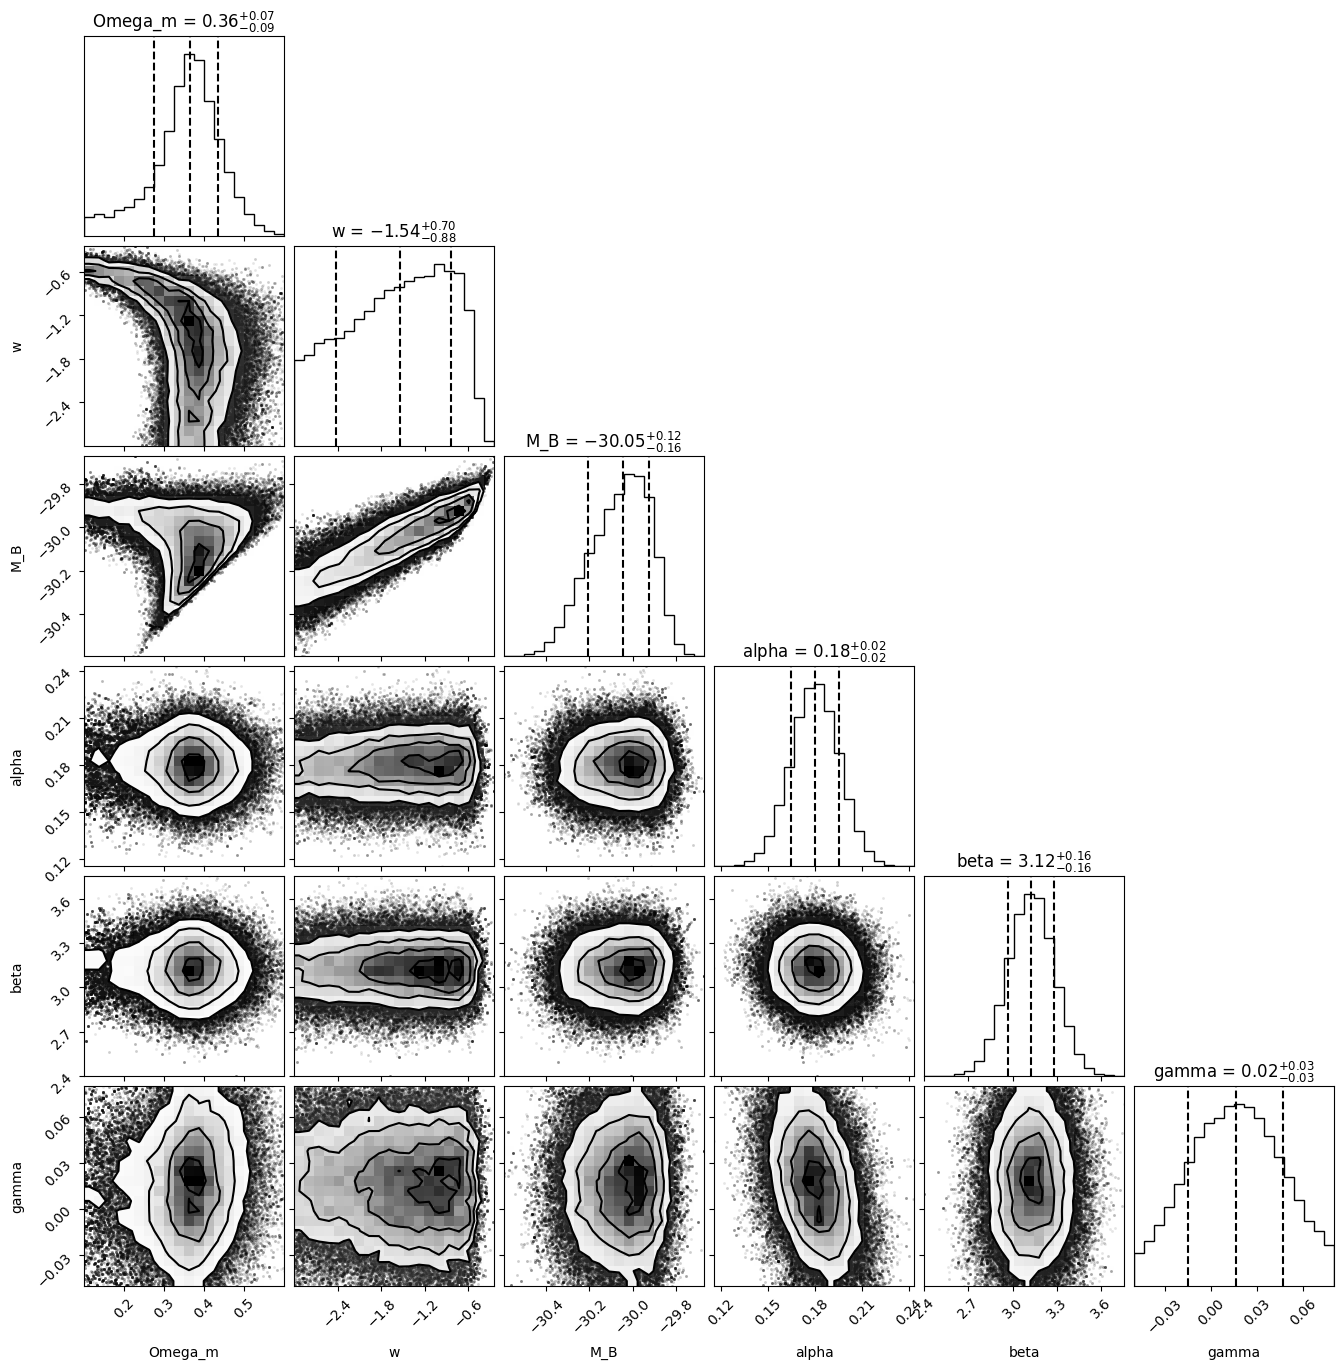

In [ ]:
import corner

fig = corner.corner(flat, labels=param_names, quantiles=[0.16, 0.5, 0.84], show_titles=True)
plt.show()